<a href="https://colab.research.google.com/github/stephanyanne/UNSUPERVISED-AND-SUPERVISED-DATA-SET-ARCEO-STEPHANY-ANNE-M.-/blob/main/UNSUPERVISED_DATA_SET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openneuro-py nibabel nilearn scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.4 MB/s eta 0:00:00


In [2]:
from openneuro import download

download(dataset="ds000003", target_dir="openneuro_data")


👋 Hello! This is openneuro-py 2026.3.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds000003 …


📁 Traversing directories for ds000003 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 87 files (5 concurrent downloads). 
✅ Finished downloading ds000003.
 
🧠 Please enjoy your brains.
 


In [3]:
from openneuro import download

download(dataset="ds000003", target_dir="openneuro_data")


👋 Hello! This is openneuro-py 2026.3.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds000003 …


📁 Traversing directories for ds000003 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 87 files (5 concurrent downloads). 
✅ Finished downloading ds000003.
 
🧠 Please enjoy your brains.
 


In [4]:
import os

mri_file = None

for root, dirs, files in os.walk("openneuro_data"):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            mri_file = os.path.join(root, file)
            break
    if mri_file:
        break

print("MRI file found:", mri_file)

MRI file found: openneuro_data/sub-03/anat/sub-03_T1w.nii.gz


In [5]:
import nibabel as nib

img = nib.load(mri_file)

print("MRI shape:", img.shape)

MRI shape: (160, 192, 192)


In [6]:
import numpy as np

data = img.get_fdata()

X = data.reshape(-1, data.shape[-1])

print("Feature matrix shape:", X.shape)

Feature matrix shape: (30720, 192)


In [7]:
from sklearn.cluster import KMeans

sample = X[:5000]  # sample to avoid memory issues

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(sample)

labels = kmeans.labels_

print("Cluster labels:", labels[:10])

Cluster labels: [1 1 1 1 1 1 1 1 1 1]


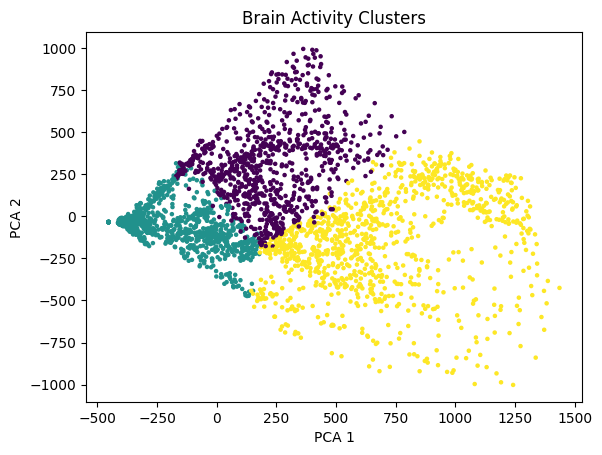

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(sample)

plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels, s=5)

plt.title("Brain Activity Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()